Filas antes: 32581
Filas después: 28638
Filas eliminadas: 3943
         person_age  person_income  person_emp_length     loan_amnt  \
count  21568.000000   2.156800e+04       21568.000000  21568.000000   
mean      28.660979   6.514939e+04           3.475473   9481.217545   
std        6.577067   5.417122e+04           3.310146   6243.139518   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       24.000000   3.720000e+04           1.000000   5000.000000   
50%       27.000000   5.400000e+04           3.000000   8000.000000   
75%       32.000000   7.800000e+04           5.000000  12000.000000   
max       84.000000   2.039784e+06          41.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  
count   21568.000000         21568.000000                21568.000000  
mean       11.128564             0.170990                    6.342220  
std         3.198103             0.106662                    4.300438  
min      

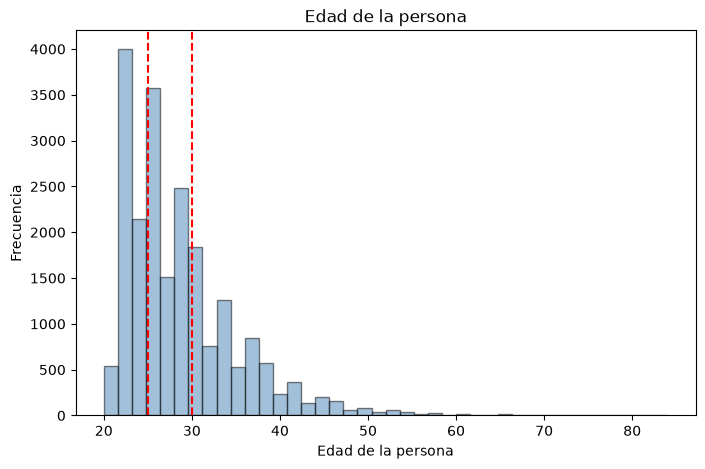

person_income
(42564.0, 69000.0]      7251
(3999.999, 42564.0]     7190
(69000.0, 2039784.0]    7127
Name: count, dtype: int64


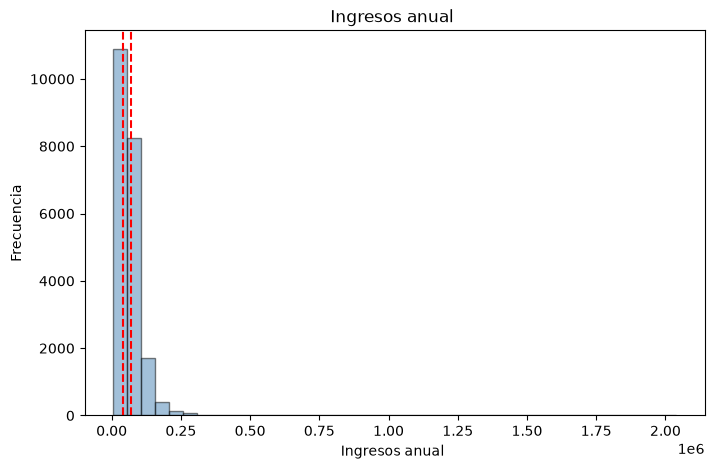

person_emp_length
(-0.001, 2.0]    9820
(4.0, 41.0]      6128
(2.0, 4.0]       5620
Name: count, dtype: int64


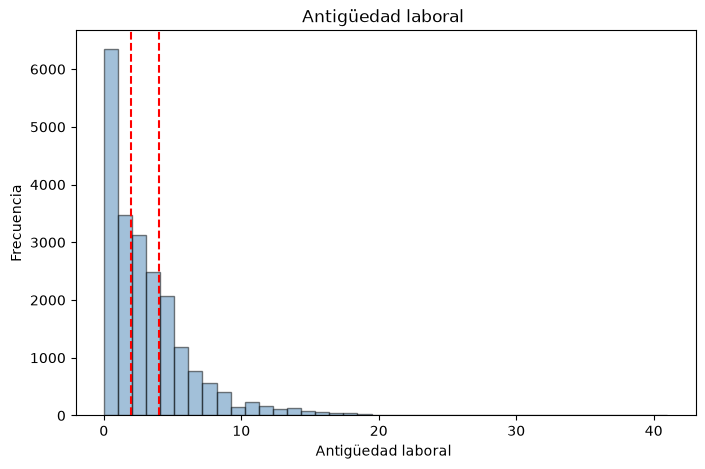

loan_amnt
(499.999, 6000.0]     8177
(10000.0, 35000.0]    7172
(6000.0, 10000.0]     6219
Name: count, dtype: int64


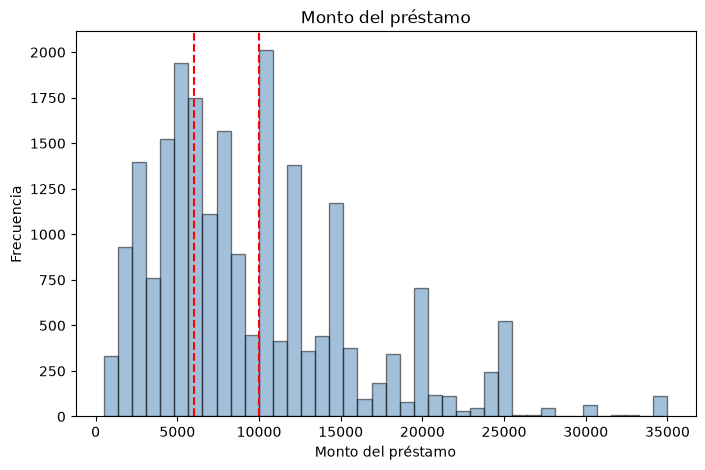

loan_int_rate
(5.419, 9.63]     7267
(9.63, 12.69]     7221
(12.69, 23.22]    7080
Name: count, dtype: int64


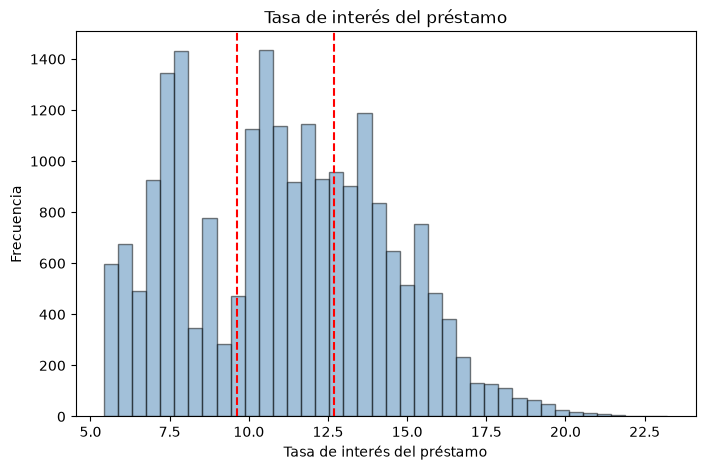

loan_percent_income
(-0.001, 0.11]    7743
(0.11, 0.2]       7147
(0.2, 0.83]       6678
Name: count, dtype: int64


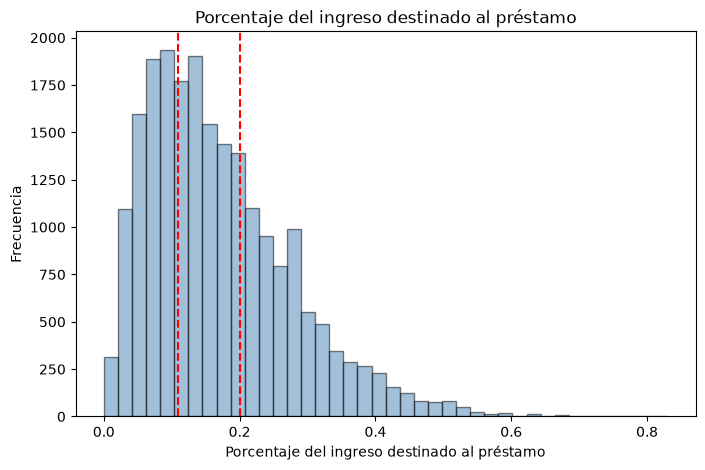

cb_person_cred_hist_length
(1.999, 4.0]    10267
(7.0, 30.0]      7088
(4.0, 7.0]       4213
Name: count, dtype: int64


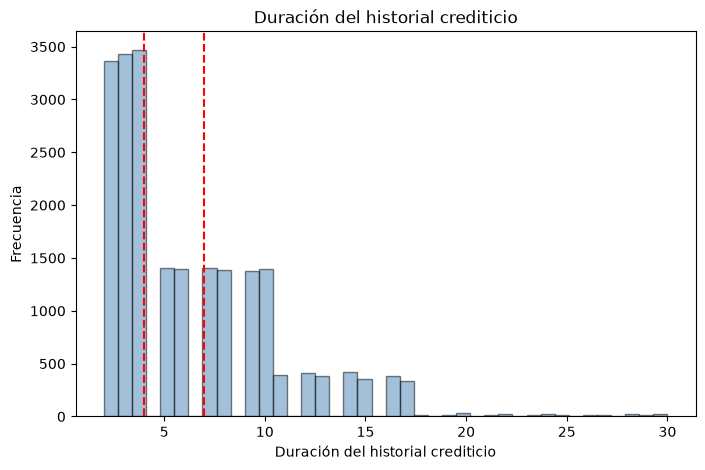

person_age                         0
person_income                      0
person_home_ownership              0
person_emp_length                  0
loan_intent                        0
loan_grade                         0
loan_amnt                          0
loan_int_rate                      0
loan_status                        0
loan_percent_income                0
cb_person_default_on_file          0
cb_person_cred_hist_length         0
person_age_disc                    0
person_income_disc                 0
person_emp_length_disc             0
loan_amnt_disc                     0
loan_int_rate_disc                 0
loan_percent_income_disc           0
cb_person_cred_hist_length_disc    0
dtype: int64
person_age_disc                    3
person_income_disc                 3
person_emp_length_disc             3
loan_amnt_disc                     3
loan_int_rate_disc                 3
loan_percent_income_disc           3
cb_person_cred_hist_length_disc    3
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(f"credit_risk_dataset.csv")

# df[...] : devuelve solo las filas donde el valor es TRUE. Es un filtro


df_limpio = df.dropna()

print("Filas antes:", len(df))
print("Filas después:", len(df_limpio))
print("Filas eliminadas:", len(df) - len(df_limpio))

# Filtro 1: eliminar las edades imposibles (> 100 años)

df_limpio = df_limpio[df_limpio['person_age'] <= 100]

# Filtro 2: la antiguedad laboral no puede superar (edad - 18)
df_limpio = df_limpio[df_limpio['person_emp_length'] <= df_limpio['person_age'] - 18]



df_limpio = df_limpio.reset_index(drop=True)

columns_names = {
    'person_age': 'Edad de la persona',
    'person_income': 'Ingresos anual ',
    'person_home_ownership': 'Tipo de tenencia de vivienda',
    'person_emp_length': 'Antigüedad laboral ',
    'loan_intent': 'Propósito del préstamo',
    'loan_grade': 'Grado del préstamo',
    'loan_amnt': 'Monto del préstamo',
    'loan_int_rate': 'Tasa de interés del préstamo',
    'loan_status': 'Estado del préstamo',
    'loan_percent_income': 'Porcentaje del ingreso destinado al préstamo',
    'cb_person_default_on_file': 'Default histórico registrado',
    'cb_person_cred_hist_length': 'Duración del historial crediticio',
}

columns_cuantils = ['person_age','person_income','person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


print(df_limpio[columns_cuantils].describe())


for col in columns_cuantils:
    discrete_columns, edges = pd.qcut(df_limpio[col], q=3, labels=["bajo", "medio", "alto"], retbins=True)

    plt.figure(figsize = (8, 5))
    plt.hist(df_limpio[col], bins = 40, color = 'steelblue', edgecolor = 'black', alpha = 0.5)
    plt.axvline(x = edges[1], color = 'red', linestyle = '--')
    plt.axvline(x = edges[2], color = 'red', linestyle = '--')
    plt.title(columns_names.get(col, col))
    plt.xlabel(columns_names.get(col, col))
    plt.ylabel('Frecuencia')
    print(pd.qcut(df_limpio[col], q=3).value_counts())
    plt.show()

    df_limpio[col + '_disc'] = pd.qcut(df_limpio[col], q=3, labels=["bajo", "medio", "alto"])


# Descripcion del grafo propuesto: 

df_edges = [
    ('person_age_disc', 'loan_intent'),                   # A → E
    ('person_age_disc', 'person_income_disc'),                 # A → B
    ('person_age_disc', 'cb_person_cred_hist_length_disc'),    # A → L
    ('person_age_disc', 'person_emp_length_disc'),             # A → D
    ('loan_intent', 'person_home_ownership'),        # E → C
    ('person_income_disc', 'loan_percent_income_disc'),        # B → J
    ('person_income_disc', 'person_home_ownership'),      # B → C
    ('person_income_disc', 'loan_amnt_disc'),                  # B → G
    ('person_income_disc', 'loan_int_rate_disc'),              # B → H
    ('person_income_disc', 'loan_grade'),                 # B → F
    ('person_income_disc', 'cb_person_default_on_file'),  # B → K
    ('person_emp_length_disc', 'person_home_ownership'),  # D → C
    ('loan_grade', 'loan_status'),                   # F → I
    ('loan_int_rate_disc', 'loan_status'),                # H → I
    ('loan_percent_income_disc', 'loan_status'),          # J → I
    ('cb_person_default_on_file', 'loan_status'),    # K → I
    ('loan_amnt_disc', 'loan_status'),                    # G → I
]


# print(df_limpio.isna().sum())

# print(df_limpio[[c+'_disc' for c in columns_cuantils]].nunique())

### Parte 1 - Red Bayesiana

Las variables a ocupar son:

A = person_age: Edad del solicitante 
B = person_income: Ingreso anual 
C = person_home_ownership: Tipo de tenencia de vivienda (arrienda / hipoteca / propia / otro)  
D = person_emp_length: Años de antigüedad laboral  
E = loan_intent: Propósito del préstamo (educación, salud, personal, etc.)  
F = loan_grade: Grado del préstamo según solvencia (A = alta solvencia / bajo riesgo; G = la más baja / mayor riesgo)  
G = loan_amnt: Monto solicitado  
H = loan_int_rate: Tasa de interés del préstamo  
I = loan_status: Estado: (0 = no default, 1 = default)  
J = loan_percent_income: Monto del préstamo como % del ingreso  
K = cb_person_default_on_file: Si tiene un default histórico registrado (Y/N)  
L = cb_person_cred_hist_length: Largo del historial crediticio (años)  


JUSTIFICAR DEPENDENCIAS


A → {E, B, L, D}
B → {J, C, G, H, F, K}
G → J
J → I
E → C, D → C
{F, H, J, K, G} → I

1. Edad: A → {E,B,L,D}

La edad condiciona aspectos asociados a la etapa de vida del solicitante, como ingreso, antigüedad laboral, historial crediticio y propósito del préstamo.

2. Ingreso: B → {J,C,G,H,F,K}

El ingreso representa la capacidad económica del solicitante y se relaciona con el monto solicitado, condiciones del crédito, vivienda y antecedentes crediticios.

3. Tenencia de vivienda: {B,D,E\} → C

La tenencia de vivienda se relaciona con la capacidad económica, estabilidad laboral y necesidades financieras del solicitante.

4. Riesgo de default: {F,H,J,K,G\} → I

El default depende de factores que representan riesgo y capacidad de pago, como grado, tasa, monto, proporción del ingreso y antecedentes de incumplimiento.


Las inferencias más interesantes tienen como objetivo loan_status (I):

1. Influencia de la carga financiera sobre el default: P(I=1|J= alto)

    Determinar cómo cambia la probabilidad de default cuando el monto del préstamo representa un porcentaje alto del ingreso. Esto permite evaluar si una mayor carga financiera relativa aumenta el riesgo de incumplimiento.

2. Influencia del historial de default y grado crediticio: P(I=1| K=Y,F=bajo)
    Calcular la probabilidad de default cuando el solicitante ya posee un default registrado y además presenta un grado crediticio de mayor riesgo. Permite analizar cómo dos indicadores de riesgo combinados modifican la probabilidad de incumplimiento.

3. Perfil de alto riesgo combinando evidencias: P(I=1|J=alto, H=alta, G=alto, K=Y)

    Estimar la probabilidad de default para una persona cuyo préstamo representa una proporción elevada de sus ingresos, posee una tasa de interés alta, solicita un monto elevado y tiene antecedentes de default. Esta inferencia aprovecha mejor la red bayesiana al combinar múltiples evidencias para evaluar un perfil crediticio completo.








Necesitamos que cada variable tenga un número finito y pequeño de categorías. 
El problema actual con el dataset es que algunas columnas tienen numeros continuos que podrian tomar infinitos valores
Por ende, se discretizaran: tomar las variables continuas y ingresarlas en una "caja" (bins); que para este caso, cada bin tendra aproximadamente la misma cantidad de gente  
Esto sera hecho diviendo los datos en cuantiles:
  - si se divide la variable "person_income" en 4 cajas, cada caja tiene un 25% de los datos. 

Estas seran las variables a discretizar(que son numéricas): 
person_age
person_income
person_emp_length
loan_amnt
loan_int_rate
loan_percent_income
cb_person_cred_hist_length


Cada caja que se agrega tiene un costo, y el costo cae sobre las CPD's

Mirando el nodo objetivo I (status) Tiene 5 padres: F, H, J, K, G
La tabla de I tiene que dar una probabilidad para cada combinación posible de valores de sus 5 padres. 
Si cada padre tiene "n" cajas, el numero de combinaciones es: n * n * n * n * n = n^5


Ahora, porque se elegiria cuantiles para la variable "income"? Porque es una variable muy sesgada y los cuantiles resuelven este problema



Cada variable tiene su necesidad segun su histograma. 

A : person_age => cuantiles: media 28.7 > med 27
B : person_income => cuantiles: media 65k > med 54k
D : person_emp_length => cuantiles: media 3.5 > med 3
G : loan_amnt => cuantiles: media 9481 > med 8000
H : loan_int_rate => cuantiles : mediana ≈ 11
J : loan_percent_income => cuantiles: media 0.17 > med 0.15
L : cb_person_cred_hist_length => cuantiles: media 6.3 > med 5


Al momento de guardar las variables discretizadas, se guardaran en el mismo DataFrame, pero agregandolas a este, no sobreescribiendo el 
archivo, para asi tener un respaldo de los datos originales. 
Todas las variables a discretizar se les agregara el sufijo "_disc"


